Loading MNIST data...
Original training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28, 1)

Federated Learning Experiment: FedDAAW vs FedAvg vs FedProx

Performing Non-IID data partitioning...
[Non-IID Partition by Ratio Completed] Total samples: 60000
Client data size → min: 120, max: 6000, mean: 3000.0
Client data ratio (actual): [0.1, 0.1, 0.1, 0.1, 0.05, 0.05, 0.05, 0.1, 0.1, 0.1, 0.005, 0.005, 0.02, 0.03, 0.002, 0.003, 0.002, 0.003, 0.04, 0.04]

Starting federated learning training...
Global rounds: 30, Clients selected per round: 15
Local training epochs: 1, Batch size: 40
FedProx mu: 0.01

Global Round 1/30

[FedDAAW Method]
DA selected clients: [11, 8, 7, 13, 3, 16, 0, 6, 17, 5, 19, 9, 4, 18, 1]
DA aggregation weights: [0.03167481 0.07351194 0.09924772 0.07038846 0.04843606 0.01319784
 0.11350139 0.07232414 0.02199639 0.07047644 0.09040517 0.05265936
 0.07522766 0.09172496 0.07522766]

[FedAvg Method]
FedAvg selected clients: [14, 9, 11, 17, 10, 12, 2, 1, 13, 7, 3, 5


[FedAvg Method]
FedAvg selected clients: [5, 19, 9, 4, 17, 2, 8, 11, 6, 16, 15, 1, 12, 18, 10]

[FedProx Method]
FedProx selected clients: [10, 17, 0, 19, 15, 11, 2, 13, 5, 12, 18, 4, 7, 9, 14]

Round 8 Results:
  FedDAAW Accuracy: 0.8616
  FedAvg Accuracy: 0.8117
  FedProx Accuracy: 0.8247

Global Round 9/30

[FedDAAW Method]
DA selected clients: [16, 5, 9, 13, 14, 7, 19, 8, 3, 17, 4, 0, 6, 1, 18]
DA aggregation weights: [0.06641107 0.0654495  0.0659642  0.06323913 0.06801196 0.06900829
 0.06803778 0.06579688 0.06659216 0.06571104 0.06510695 0.07029245
 0.06634084 0.06747351 0.06656427]

[FedAvg Method]
FedAvg selected clients: [1, 2, 16, 8, 5, 10, 15, 13, 19, 7, 6, 17, 0, 3, 4]

[FedProx Method]
FedProx selected clients: [17, 18, 3, 1, 13, 10, 2, 5, 9, 4, 15, 6, 0, 19, 7]

Round 9 Results:
  FedDAAW Accuracy: 0.8701
  FedAvg Accuracy: 0.8510
  FedProx Accuracy: 0.8424

Global Round 10/30

[FedDAAW Method]
DA selected clients: [19, 18, 7, 8, 1, 3, 5, 17, 14, 6, 13, 16, 9, 11, 0]
DA a


[FedAvg Method]
FedAvg selected clients: [17, 2, 0, 13, 11, 12, 15, 10, 19, 4, 5, 9, 1, 6, 16]

[FedProx Method]
FedProx selected clients: [5, 2, 8, 13, 16, 6, 11, 1, 4, 12, 3, 17, 15, 7, 0]

Round 20 Results:
  FedDAAW Accuracy: 0.9352
  FedAvg Accuracy: 0.9205
  FedProx Accuracy: 0.9228

Global Round 21/30

[FedDAAW Method]
DA selected clients: [6, 4, 11, 16, 0, 14, 18, 5, 9, 3, 13, 8, 1, 7, 17]
DA aggregation weights: [0.066547   0.06553441 0.06632481 0.0699302  0.06873225 0.06800114
 0.06657959 0.06635029 0.06651027 0.06655109 0.06687857 0.06608556
 0.06740258 0.06808988 0.06048236]

[FedAvg Method]
FedAvg selected clients: [12, 5, 3, 4, 8, 0, 13, 7, 17, 11, 19, 9, 15, 10, 14]

[FedProx Method]
FedProx selected clients: [9, 10, 4, 13, 18, 2, 12, 0, 17, 6, 11, 16, 7, 8, 19]

Round 21 Results:
  FedDAAW Accuracy: 0.9366
  FedAvg Accuracy: 0.9273
  FedProx Accuracy: 0.9246

Global Round 22/30

[FedDAAW Method]
DA selected clients: [11, 16, 4, 8, 9, 18, 0, 14, 1, 3, 5, 17, 13, 7, 19]


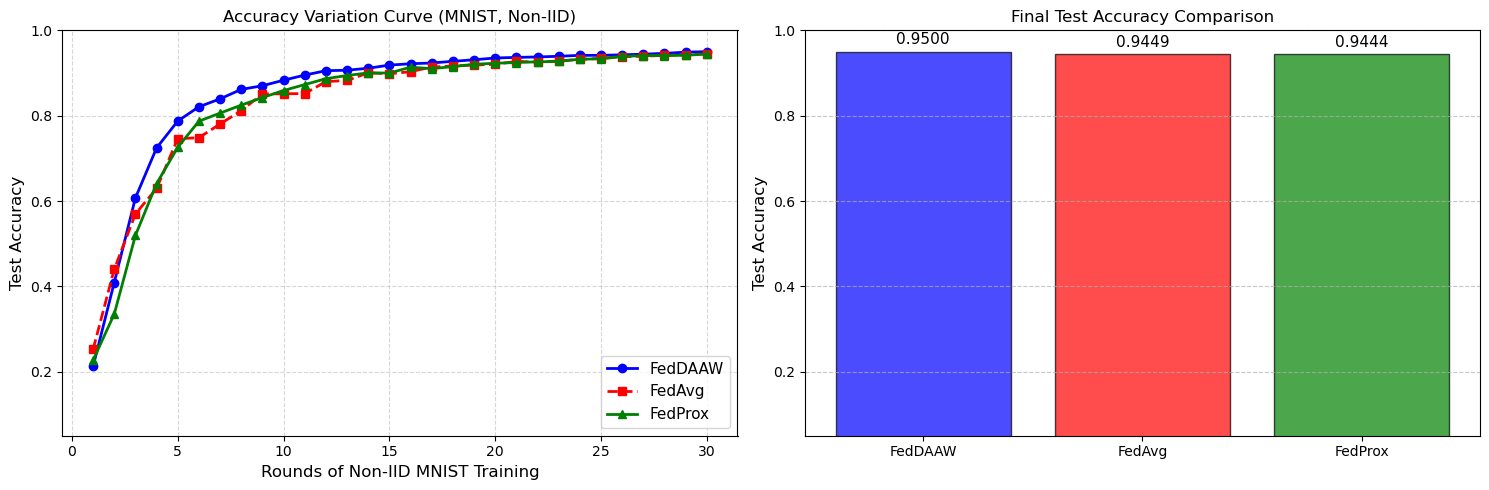


Final Experimental Results (Three-way Comparison)
FedDAAW Final Accuracy: 0.9500
FedAvg Final Accuracy: 0.9449
FedProx Final Accuracy: 0.9444

----------------------------------------
Improvement Analysis:
FedDAAW vs FedAvg: +0.0051 (0.51%)
FedDAAW vs FedProx: +0.0056 (0.56%)

----------------------------------------
Convergence Analysis (threshold = 90%):
  FedDAAW reached 90% accuracy at round 12
  FedAvg reached 90% accuracy at round 14
  FedProx reached 90% accuracy at round 14


In [2]:
"""
Federated Learning Comparison: FedDAAW vs FedAvg vs FedProx
Dataset: MNIST (Non-IID distribution)
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from scipy import stats
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import SGD
from tensorflow.keras import layers, models

# ============================================================
# 1. 全局参数配置
# ============================================================

# Total number of clients participating in training in the federated learning system (20 devices/users in total)
NUM_CLIENTS = 20

# Number of dataset classes (MNIST has 10 digit classes from 0 to 9)
NUM_CLASSES = 10

# Input feature dimension (for CNN, we use image shape instead of flattening)
IMAGE_SHAPE = (28, 28, 1)

# Size of time window for calculating client historical performance trends (accuracy of the last 5 rounds is used to fit trends via linear regression)
WINDOW_SIZE = 5

# Weight of "historical performance trend" in client selection score (higher value means more emphasis on clients' past performance improvement)
WEIGHT_HISTORY = 0.6

# Weight of "data quality (similarity with global model)" in client selection score (reflects the potential contribution of local data to the global model)
WEIGHT_DATA = 0.3

# Weight of "system status (simulated indicators such as device power, network condition, etc.)" in client selection score
WEIGHT_SYS = 0.1

# Number of clients selected from all clients to participate in training per federated learning round (select 15 out of 20)
NUM_SELECT_CLIENTS = 15

# Coefficient for smoothing current accuracy and historical average accuracy during adaptive aggregation (0.9 means more trust in current performance)
# Formula: smoothed_acc = LAMBDA_SMOOTH * current_acc + (1 - LAMBDA_SMOOTH) * avg_acc
LAMBDA_SMOOTH = 0.9

# Number of training epochs executed locally by each selected client (local fine-tuning intensity)
LOCAL_EPOCHS = 1  # Reduce epochs to speed up training

# Learning rate
LEARNING_RATE = 0.01

# Number of samples processed per batch during local training (affects memory usage and convergence stability)
BATCH_SIZE = 40

# Total number of communication rounds executed by the global coordinator (server) (i.e., federated learning iteration count)
NUM_GLOBAL_EPOCHS = 30  # Reduce global rounds to speed up demonstration

# ========== FedProx Proximal Term Coefficient ==========
# Controls the strength of the proximal term: mu/2 * ||w - w_global||²
# Recommended range: 0.001 ~ 0.1
FEDPROX_MU = 0.01

# Set random seeds for TensorFlow and NumPy to ensure experimental reproducibility (consistent results for the same code each run)
tf.random.set_seed(42)
np.random.seed(42)


# ============================================================
# 2. 加载数据
# ============================================================

print("Loading MNIST data...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Prepare training data (keep original shape for data partitioning)
x_train_original = x_train
y_train_original = y_train

# Prepare test data (for final evaluation)
x_test_cnn = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
y_test_categorical = tf.keras.utils.to_categorical(y_test, 10)

print(f"Original training set shape: {x_train_original.shape}")
print(f"Test set shape: {x_test_cnn.shape}")


# ============================================================
# 3. 工具函数
# ============================================================

def normalize_scores(scores):
    """Normalize scores to the range [0, 1]"""
    if len(scores) == 0:
        return np.array([])
    min_score = np.min(scores)
    max_score = np.max(scores)
    if max_score - min_score < 1e-6:
        return np.ones_like(scores) / len(scores)
    return (scores - min_score) / (max_score - min_score)


def build_model():
    """Build CNN model"""
    model = Sequential([
        Input(shape=IMAGE_SHAPE),
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    
    model.compile(
        optimizer=SGD(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model


# ============================================================
# 4. Non-IID数据划分
# ============================================================

def load_and_partition_mnist_non_iid(
    num_clients=10,
    client_ratios=None,
    alpha=0.5,
    val_ratio=0.3
):
    """
    Partition MNIST data in a Non-IID manner using Dirichlet distribution
    """
    x_data = x_train_original
    y_data = y_train_original

    total_samples = len(x_data)

    if client_ratios is None:
        client_ratios = [1.0 / num_clients] * num_clients
    else:
        assert len(client_ratios) == num_clients, "Length of client_ratios must equal num_clients"
        assert abs(sum(client_ratios) - 1.0) < 1e-6, "Sum of client_ratios must be 1.0"

    client_sizes = [int(ratio * total_samples) for ratio in client_ratios]
    diff = total_samples - sum(client_sizes)
    for i in range(diff):
        client_sizes[i] += 1

    class_indices = [np.where(y_data == i)[0] for i in range(NUM_CLASSES)]
    used_mask = np.zeros(total_samples, dtype=bool)

    client_data = []

    for i in range(num_clients):
        needed = client_sizes[i]
        class_probs = np.random.dirichlet([alpha] * NUM_CLASSES)

        selected_indices = []
        remaining = needed

        class_order = np.random.permutation(NUM_CLASSES)
        for class_id in class_order:
            n_from_class = int(class_probs[class_id] * needed)
            if n_from_class == 0 and remaining > 0:
                n_from_class = 1

            if n_from_class > remaining:
                n_from_class = remaining

            available_indices = class_indices[class_id][~used_mask[class_indices[class_id]]]
            n_available = len(available_indices)
            if n_available <= n_from_class:
                selected = available_indices
            else:
                selected = np.random.choice(available_indices, size=n_from_class, replace=False)

            selected_indices.extend(selected)
            used_mask[selected] = True
            remaining -= len(selected)

            if remaining <= 0:
                break

        if remaining > 0:
            all_remaining = np.where(~used_mask)[0]
            if len(all_remaining) < remaining:
                selected = all_remaining
            else:
                selected = np.random.choice(all_remaining, size=remaining, replace=False)
            selected_indices.extend(selected)
            used_mask[selected] = True

        assert len(selected_indices) == needed, f"Client {i} sample count error, expected {needed}, actual {len(selected_indices)}"

        selected_indices = np.array(selected_indices)
        np.random.shuffle(selected_indices)

        X_local = x_data[selected_indices]
        y_local = y_data[selected_indices]

        X_local = X_local.reshape(-1, 28, 28, 1).astype('float32') / 255.0

        split = int((1 - val_ratio) * len(X_local))
        client_data.append({
            'X_train': X_local[:split],
            'y_train': y_local[:split],
            'X_val': X_local[split:],
            'y_val': y_local[split:],
            'class_probs': class_probs
        })

    actual_sizes = [len(d['X_train']) + len(d['X_val']) for d in client_data]
    print(f"[Non-IID Partition by Ratio Completed] Total samples: {total_samples}")
    print(f"Client data size → min: {min(actual_sizes)}, max: {max(actual_sizes)}, mean: {np.mean(actual_sizes):.1f}")
    print(f"Client data ratio (actual): {[size/total_samples for size in actual_sizes]}")

    return client_data


# ============================================================
# 5. 基础客户端类 (用于FedAvg和FedDAAW)
# ============================================================

class Client:
    def __init__(self, client_id, data_dict):
        self.client_id = client_id
        self.X_train = data_dict['X_train']
        self.y_train = data_dict['y_train']
        self.X_val = data_dict['X_val']
        self.y_val = data_dict['y_val']
        self.model = build_model()
        self.acc_history = []
        self.acc_trend = 0.0
        self.data_similarity = 0.0
        self.sys_score = np.random.uniform(0.7, 1.0)

    def local_train(self, global_weights):
        """Perform local training using global weights"""
        self.model.set_weights(global_weights)
        self.model.fit(
            self.X_train,
            self.y_train,
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0,
            validation_data=(self.X_val, self.y_val)
        )
        return self.model.get_weights()

    def local_evaluate(self):
        """Evaluate model on local validation set"""
        y_pred = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)
        acc = accuracy_score(self.y_val, y_pred)
        self.acc_history.append(acc)

        hist = self.acc_history
        if len(hist) >= WINDOW_SIZE:
            x = np.arange(WINDOW_SIZE)
            slope, _, _, _, _ = stats.linregress(x, hist[-WINDOW_SIZE:])
            self.acc_trend = slope
        elif len(hist) >= 2:
            x = np.arange(len(hist))
            slope, _, _, _, _ = stats.linregress(x, hist)
            self.acc_trend = slope
        else:
            self.acc_trend = 0.0

        return acc

    def get_historical_performance_factor(self):
        """Get historical performance factor"""
        return max(0, self.acc_trend) + 0.1

    def get_data_quality_factor(self):
        """Get data quality factor"""
        return max(0.1, min(1.0, self.data_similarity))

    def get_system_factor(self):
        """Get system factor"""
        return self.sys_score


# ============================================================
# 6. FedProx客户端类 (带近端项)
# ============================================================

class FedProxClient(Client):
    """
    FedProx Client: Adds a proximal term to the local training loss
    Proximal term: mu/2 * ||w - w_global||²
    """
    def __init__(self, client_id, data_dict, mu=0.01):
        super().__init__(client_id, data_dict)
        self.mu = mu
        self.global_weights = None

    def local_train(self, global_weights):
        """
        Perform local training with FedProx proximal term
        Total loss = original_loss + (mu/2) * ||w - w_global||²
        """
        self.global_weights = [w.copy() for w in global_weights]
        self.model.set_weights(global_weights)

        optimizer = SGD(learning_rate=LEARNING_RATE)

        train_dataset = tf.data.Dataset.from_tensor_slices((self.X_train, self.y_train))
        train_dataset = train_dataset.shuffle(buffer_size=len(self.X_train)).batch(BATCH_SIZE)

        for epoch in range(LOCAL_EPOCHS):
            for batch_x, batch_y in train_dataset:
                with tf.GradientTape() as tape:
                    predictions = self.model(batch_x, training=True)
                    loss = tf.keras.losses.sparse_categorical_crossentropy(batch_y, predictions)
                    loss = tf.reduce_mean(loss)

                    # FedProx proximal term: (mu/2) * ||w - w_global||²
                    proximal_loss = 0.0
                    for local_w, global_w in zip(self.model.trainable_weights, self.global_weights):
                        proximal_loss += tf.reduce_sum(tf.square(local_w - global_w))
                    proximal_loss = (self.mu / 2.0) * proximal_loss

                    total_loss = loss + proximal_loss

                grads = tape.gradient(total_loss, self.model.trainable_weights)
                optimizer.apply_gradients(zip(grads, self.model.trainable_weights))

        return self.model.get_weights()


# ============================================================
# 7. 服务器: FedDAAW
# ============================================================

class ServerDA:
    def __init__(self):
        self.global_model = build_model()
        self.global_weights = self.global_model.get_weights()
        self.global_acc_history = []

    def calculate_selection_score(self, clients):
        """Calculate client selection score"""
        scores = []
        for c in clients:
            hist_factor = c.get_historical_performance_factor()
            data_factor = c.get_data_quality_factor()
            sys_factor = c.get_system_factor()

            score = (WEIGHT_HISTORY * hist_factor +
                    WEIGHT_DATA * data_factor +
                    WEIGHT_SYS * sys_factor)
            scores.append(score)

        return np.array(scores)

    def select_clients(self, clients):
        """Select clients based on scores"""
        scores = self.calculate_selection_score(clients)
        probs = normalize_scores(scores)
        probs = probs / probs.sum()

        if np.any(np.isnan(probs)) or np.all(probs == 0):
            probs = np.ones(len(clients)) / len(clients)

        indices = np.random.choice(
            len(clients),
            size=min(NUM_SELECT_CLIENTS, len(clients)),
            replace=False,
            p=probs
        )

        selected = [clients[i] for i in indices]
        print(f"DA selected clients: {[c.client_id for c in selected]}")
        return selected

    def calculate_adaptive_weights(self, selected_clients):
        """Calculate adaptive aggregation weights"""
        weights = []
        for c in selected_clients:
            if len(c.acc_history) == 0:
                weights.append(0.1)
            else:
                current = c.acc_history[-1]
                avg = np.mean(c.acc_history) if len(c.acc_history) > 0 else current
                smoothed = LAMBDA_SMOOTH * current + (1 - LAMBDA_SMOOTH) * avg
                weights.append(smoothed)

        weights = np.array(weights)
        if np.sum(weights) > 0:
            weights = weights / np.sum(weights)
        else:
            weights = np.ones(len(weights)) / len(weights)

        return weights

    def update_data_similarity(self, selected_clients, client_weights_list):
        """Update data similarity (based on cosine similarity of first layer weights)"""
        if len(selected_clients) == 0:
            return

        global_first_layer = self.global_weights[0].flatten()
        global_norm = np.linalg.norm(global_first_layer)

        for i, (c, cw) in enumerate(zip(selected_clients, client_weights_list)):
            client_first_layer = cw[0].flatten()
            client_norm = np.linalg.norm(client_first_layer)

            if global_norm > 1e-8 and client_norm > 1e-8:
                similarity = np.dot(global_first_layer, client_first_layer) / (global_norm * client_norm)
                c.data_similarity = max(0, min(1, similarity))
            else:
                c.data_similarity = 0.5

    def aggregate(self, selected_clients, client_weights_list):
        """Aggregate client models"""
        if len(selected_clients) == 0:
            return

        adaptive_w = self.calculate_adaptive_weights(selected_clients)
        print(f"DA aggregation weights: {adaptive_w}")

        new_weights = []
        for layer_idx in range(len(self.global_weights)):
            weighted_sum = np.zeros_like(self.global_weights[layer_idx])
            for alpha, cw in zip(adaptive_w, client_weights_list):
                weighted_sum += alpha * cw[layer_idx]
            new_weights.append(weighted_sum)

        self.global_weights = new_weights
        self.update_data_similarity(selected_clients, client_weights_list)

    def evaluate(self, test_data=None, test_labels=None):
        """Evaluate global model"""
        if test_data is None:
            test_data = x_test_cnn
            test_labels = y_test_categorical

        self.global_model.set_weights(self.global_weights)
        y_pred = np.argmax(self.global_model.predict(test_data, verbose=0), axis=1)

        if test_labels.ndim > 1:
            y_true = np.argmax(test_labels, axis=1)
        else:
            y_true = test_labels

        acc = accuracy_score(y_true, y_pred)
        self.global_acc_history.append(acc)

        return acc


# ============================================================
# 8. 服务器: FedAvg (基线)
# ============================================================

class ServerFedAvg:
    def __init__(self):
        self.global_model = build_model()
        self.global_weights = self.global_model.get_weights()
        self.global_acc_history = []

    def select_clients(self, clients):
        """Randomly select clients"""
        indices = np.random.choice(
            len(clients),
            size=min(NUM_SELECT_CLIENTS, len(clients)),
            replace=False
        )
        selected = [clients[i] for i in indices]
        print(f"FedAvg selected clients: {[c.client_id for c in selected]}")
        return selected

    def aggregate(self, client_weights_list):
        """FedAvg aggregation: simple average"""
        if len(client_weights_list) == 0:
            return

        new_weights = []
        for layer_idx in range(len(self.global_weights)):
            avg_layer = np.zeros_like(self.global_weights[layer_idx])
            for cw in client_weights_list:
                avg_layer += cw[layer_idx]
            avg_layer = avg_layer / len(client_weights_list)
            new_weights.append(avg_layer)

        self.global_weights = new_weights

    def evaluate(self, test_data=None, test_labels=None):
        """Evaluate global model"""
        if test_data is None:
            test_data = x_test_cnn
            test_labels = y_test_categorical

        self.global_model.set_weights(self.global_weights)
        y_pred = np.argmax(self.global_model.predict(test_data, verbose=0), axis=1)

        if test_labels.ndim > 1:
            y_true = np.argmax(test_labels, axis=1)
        else:
            y_true = test_labels

        acc = accuracy_score(y_true, y_pred)
        self.global_acc_history.append(acc)

        return acc


# ============================================================
# 9. 服务器: FedProx
# ============================================================

class ServerFedProx:
    def __init__(self):
        self.global_model = build_model()
        self.global_weights = self.global_model.get_weights()
        self.global_acc_history = []

    def select_clients(self, clients):
        """Randomly select clients (same as FedAvg)"""
        indices = np.random.choice(
            len(clients),
            size=min(NUM_SELECT_CLIENTS, len(clients)),
            replace=False
        )
        selected = [clients[i] for i in indices]
        print(f"FedProx selected clients: {[c.client_id for c in selected]}")
        return selected

    def aggregate(self, client_weights_list):
        """FedProx aggregation: simple average (same as FedAvg)"""
        if len(client_weights_list) == 0:
            return

        new_weights = []
        for layer_idx in range(len(self.global_weights)):
            avg_layer = np.zeros_like(self.global_weights[layer_idx])
            for cw in client_weights_list:
                avg_layer += cw[layer_idx]
            avg_layer = avg_layer / len(client_weights_list)
            new_weights.append(avg_layer)

        self.global_weights = new_weights

    def evaluate(self, test_data=None, test_labels=None):
        """Evaluate global model"""
        if test_data is None:
            test_data = x_test_cnn
            test_labels = y_test_categorical

        self.global_model.set_weights(self.global_weights)
        y_pred = np.argmax(self.global_model.predict(test_data, verbose=0), axis=1)

        if test_labels.ndim > 1:
            y_true = np.argmax(test_labels, axis=1)
        else:
            y_true = test_labels

        acc = accuracy_score(y_true, y_pred)
        self.global_acc_history.append(acc)

        return acc


# ============================================================
# 10. 主训练函数 (三路对比)
# ============================================================

da_accuracies = []
fedavg_accuracies = []
fedprox_accuracies = []


def main():
    global da_accuracies, fedavg_accuracies, fedprox_accuracies

    print("\n" + "="*60)
    print("Federated Learning Experiment: FedDAAW vs FedAvg vs FedProx")
    print("="*60)

    # Non-IID data partitioning
    print("\nPerforming Non-IID data partitioning...")
    fixed_ratios = [0.1, 0.1, 0.1, 0.1, 0.05, 0.05, 0.05, 0.1, 0.1, 0.1,
                    0.005, 0.005, 0.02, 0.03, 0.002, 0.003, 0.002, 0.003, 0.04, 0.04]

    client_datasets = load_and_partition_mnist_non_iid(
        num_clients=NUM_CLIENTS,
        alpha=0.5,
        client_ratios=fixed_ratios,
        val_ratio=0.2
    )

    # Create three groups of clients (same data, independent models)
    clients_da = [Client(i, client_datasets[i]) for i in range(NUM_CLIENTS)]
    clients_fedavg = [Client(i, client_datasets[i]) for i in range(NUM_CLIENTS)]
    clients_fedprox = [FedProxClient(i, client_datasets[i], mu=FEDPROX_MU) for i in range(NUM_CLIENTS)]

    # Initialize servers
    server_da = ServerDA()
    server_fedavg = ServerFedAvg()
    server_fedprox = ServerFedProx()

    print(f"\nStarting federated learning training...")
    print(f"Global rounds: {NUM_GLOBAL_EPOCHS}, Clients selected per round: {NUM_SELECT_CLIENTS}")
    print(f"Local training epochs: {LOCAL_EPOCHS}, Batch size: {BATCH_SIZE}")
    print(f"FedProx mu: {FEDPROX_MU}")

    for epoch in range(NUM_GLOBAL_EPOCHS):
        print(f"\n{'='*50}")
        print(f"Global Round {epoch+1}/{NUM_GLOBAL_EPOCHS}")
        print(f"{'='*50}")

        # ========== 1. FedDAAW ==========
        print("\n[FedDAAW Method]")
        selected_da = server_da.select_clients(clients_da)

        weights_da = []
        for client in selected_da:
            client_weights = client.local_train(server_da.global_weights)
            weights_da.append(client_weights)

        for client in selected_da:
            client.local_evaluate()

        server_da.aggregate(selected_da, weights_da)
        acc_da = server_da.evaluate()
        da_accuracies.append(acc_da)

        # ========== 2. FedAvg ==========
        print("\n[FedAvg Method]")
        selected_fed = server_fedavg.select_clients(clients_fedavg)

        weights_fed = []
        for client in selected_fed:
            client_weights = client.local_train(server_fedavg.global_weights)
            weights_fed.append(client_weights)

        for client in selected_fed:
            client.local_evaluate()

        server_fedavg.aggregate(weights_fed)
        acc_fed = server_fedavg.evaluate()
        fedavg_accuracies.append(acc_fed)

        # ========== 3. FedProx ==========
        print("\n[FedProx Method]")
        selected_prox = server_fedprox.select_clients(clients_fedprox)

        weights_prox = []
        for client in selected_prox:
            client_weights = client.local_train(server_fedprox.global_weights)
            weights_prox.append(client_weights)

        for client in selected_prox:
            client.local_evaluate()

        server_fedprox.aggregate(weights_prox)
        acc_prox = server_fedprox.evaluate()
        fedprox_accuracies.append(acc_prox)

        print(f"\nRound {epoch+1} Results:")
        print(f"  FedDAAW Accuracy: {acc_da:.4f}")
        print(f"  FedAvg Accuracy: {acc_fed:.4f}")
        print(f"  FedProx Accuracy: {acc_prox:.4f}")

        # Early stopping check (if accuracy does not improve for 3 consecutive rounds for all methods)
        if epoch >= 3:
            if (da_accuracies[-1] <= da_accuracies[-2] <= da_accuracies[-3] and
                fedavg_accuracies[-1] <= fedavg_accuracies[-2] <= fedavg_accuracies[-3] and
                fedprox_accuracies[-1] <= fedprox_accuracies[-2] <= fedprox_accuracies[-3]):
                print("\nConvergence detected, stopping training early")
                break


# ============================================================
# 11. 可视化与结果输出
# ============================================================

def plot_results():
    """Plot three-way comparison results"""
    epochs_trained = len(da_accuracies)

    if epochs_trained == 0:
        print("No training data available. Please run main() first.")
        return

    plt.figure(figsize=(15, 5))

    # Subplot 1: Accuracy curves
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs_trained + 1), da_accuracies, 'b-o', linewidth=2, markersize=6, label='FedDAAW')
    plt.plot(range(1, epochs_trained + 1), fedavg_accuracies, 'r--s', linewidth=2, markersize=6, label='FedAvg')
    plt.plot(range(1, epochs_trained + 1), fedprox_accuracies, 'g-^', linewidth=2, markersize=6, label='FedProx')
    plt.xlabel('Rounds of Non-IID MNIST Training', fontsize=12)
    plt.ylabel('Test Accuracy', fontsize=12)
    plt.title('Accuracy Variation Curve (MNIST, Non-IID)', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.ylim([0.05, 1.0])

    # Subplot 2: Final accuracy comparison
    plt.subplot(1, 2, 2)
    methods = ['FedDAAW', 'FedAvg', 'FedProx']
    final_accs = [da_accuracies[-1], fedavg_accuracies[-1], fedprox_accuracies[-1]]
    colors = ['blue', 'red', 'green']

    bars = plt.bar(methods, final_accs, color=colors, alpha=0.7, edgecolor='black')
    plt.ylabel('Test Accuracy', fontsize=12)
    plt.title('Final Test Accuracy Comparison', fontsize=12)
    plt.ylim([0.05, 1.0])

    for bar, acc in zip(bars, final_accs):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{acc:.4f}', ha='center', va='bottom', fontsize=11)

    plt.grid(True, linestyle='--', alpha=0.7, axis='y')

    plt.tight_layout()
    plt.show()

    # ========== Print Final Results ==========
    print("\n" + "="*60)
    print("Final Experimental Results (Three-way Comparison)")
    print("="*60)
    print(f"FedDAAW Final Accuracy: {da_accuracies[-1]:.4f}")
    print(f"FedAvg Final Accuracy: {fedavg_accuracies[-1]:.4f}")
    print(f"FedProx Final Accuracy: {fedprox_accuracies[-1]:.4f}")

    print("\n" + "-"*40)
    print("Improvement Analysis:")
    improvement_da_vs_avg = da_accuracies[-1] - fedavg_accuracies[-1]
    improvement_da_vs_prox = da_accuracies[-1] - fedprox_accuracies[-1]
    print(f"FedDAAW vs FedAvg: +{improvement_da_vs_avg:.4f} ({improvement_da_vs_avg*100:.2f}%)")
    print(f"FedDAAW vs FedProx: +{improvement_da_vs_prox:.4f} ({improvement_da_vs_prox*100:.2f}%)")

    # Calculate convergence speed (number of rounds to reach 90% accuracy)
    da_90_idx = next((i for i, acc in enumerate(da_accuracies) if acc >= 0.9), None)
    fedavg_90_idx = next((i for i, acc in enumerate(fedavg_accuracies) if acc >= 0.9), None)
    fedprox_90_idx = next((i for i, acc in enumerate(fedprox_accuracies) if acc >= 0.9), None)

    print("\n" + "-"*40)
    print("Convergence Analysis (threshold = 90%):")
    if da_90_idx is not None:
        print(f"  FedDAAW reached 90% accuracy at round {da_90_idx + 1}")
    else:
        print("  FedDAAW did not reach 90% accuracy during training")

    if fedavg_90_idx is not None:
        print(f"  FedAvg reached 90% accuracy at round {fedavg_90_idx + 1}")
    else:
        print("  FedAvg did not reach 90% accuracy during training")

    if fedprox_90_idx is not None:
        print(f"  FedProx reached 90% accuracy at round {fedprox_90_idx + 1}")
    else:
        print("  FedProx did not reach 90% accuracy during training")


# ============================================================
# 12. 程序入口
# ============================================================

if __name__ == "__main__":
    main()
    plot_results()